In [61]:
import pandas as pd

df = pd.read_csv("movies.csv")
df.head()

,MOVIES,YEAR,GENRE,RATING,ONE-LINE,STARS,VOTES,RunTime,Gross
0,Blood Red Sky,(2021),"\r\nAction, Horror, Thriller",6.1,\r\nA woman with a mysterious illness is force...,\r\n Director:\r\nPeter Thorwarth\r\n| \r\n...,"21,062",121.0,NaN
1,Masters of the Universe: Revelation,(2021– ),"\r\nAnimation, Action, Adventure",5.0,\r\nThe war for Eternia begins again in what m...,"\r\n \r\n Stars:\r\nChris Wood, ...","17,870",25.0,NaN
2,The Walking Dead,(2010–2022),"\r\nDrama, Horror, Thriller",8.2,\r\nSheriff Deputy Rick Grimes wakes up from a...,\r\n \r\n Stars:\r\nAndrew Linco...,"885,805",44.0,NaN
3,Rick and Morty,(2013– ),"\r\nAnimation, Adventure, Comedy",9.2,\r\nAn animated series that follows the exploi...,\r\n \r\n Stars:\r\nJustin Roila...,"414,849",23.0,NaN
4,Army of Thieves,(2021),"\r\nAction, Crime, Horror",NaN,"\r\nA prequel, set before the events of Army o...",\r\n Director:\r\nMatthias Schweighöfer\r\n...,NaN,NaN,NaN


** COMANDOS DE INSPECCION RAPIDA **

Dimensiones del dataset

In [62]:
df.shape

(9999, 9)

Informacion Gneral DATASET

In [63]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9999 entries, 0 to 9998
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   MOVIES    9999 non-null   str    
 1   YEAR      9355 non-null   str    
 2   GENRE     9919 non-null   str    
 3   RATING    8179 non-null   float64
 4   ONE-LINE  9999 non-null   str    
 5   STARS     9999 non-null   str    
 6   VOTES     8179 non-null   str    
 7   RunTime   7041 non-null   float64
 8   Gross     460 non-null    str    
dtypes: float64(2), str(7)
memory usage: 703.2 KB


Estadísticas descriptivas

In [64]:
df.describe()

,RATING,RunTime
count,8179.000000,7041.000000
mean,6.921176,68.688539
std,1.220232,47.258056
min,1.100000,1.000000
25%,6.200000,36.000000
50%,7.100000,60.000000
75%,7.800000,95.000000
max,9.900000,853.000000


Valores Nulos

In [65]:
df.isnull().sum()

MOVIES         0
YEAR         644
GENRE         80
RATING      1820
ONE-LINE       0
STARS          0
VOTES       1820
RunTime     2958
Gross       9539
dtype: int64

** VERIFICACION DE VALORES FALTANTES **

Porcentaje de valores faltantes

In [66]:
(df.isnull().sum() / len(df)) * 100

MOVIES       0.000000
YEAR         6.440644
GENRE        0.800080
RATING      18.201820
ONE-LINE     0.000000
STARS        0.000000
VOTES       18.201820
RunTime     29.582958
Gross       95.399540
dtype: float64

Visualizar los NaNs

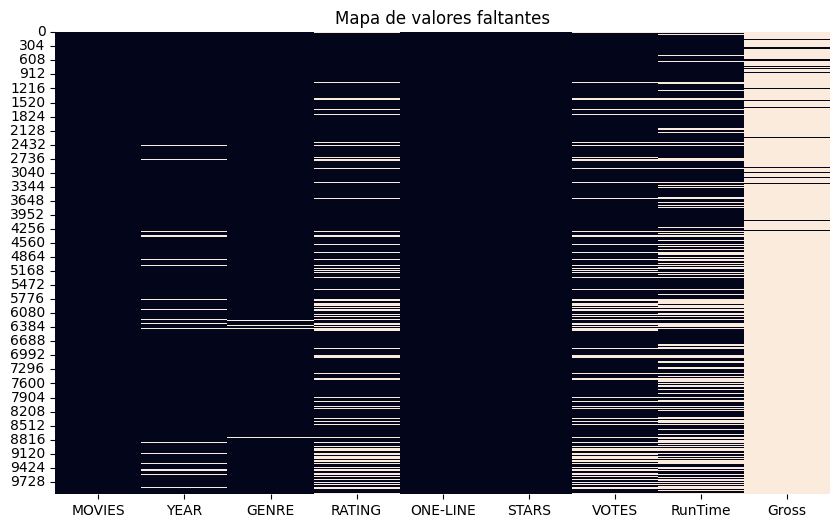

In [67]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Mapa de valores faltantes")
plt.show()

Como podemos observar la columna Gross tiene demasiados valores faltantes, por lo que procederemos a eliminarla ya que sabemos que los valores faltantes para un modelo no son provechosos

In [68]:
df = df.drop(columns=["Gross"])

Luego vamos a rellenar valores, los numericos con la media o mediana segun corresponda

In [69]:
df["RunTime"] = df["RunTime"].fillna(df["RunTime"].mean())
df["RATING"]  = df["RATING"].fillna(df["RATING"].median())
df["VOTES"]   = pd.to_numeric(df["VOTES"].astype(str).str.replace(",", ""), errors="coerce")
df["VOTES"]   = df["VOTES"].fillna(df["VOTES"].median())

Luego los categoricos con "Uknown"

In [70]:
df["GENRE"] = df["GENRE"].fillna("Unknown")
df["STARS"] = df["STARS"].fillna("Unknown")

Verificamos

In [71]:
df.isnull().sum()

MOVIES        0
YEAR        644
GENRE         0
RATING        0
ONE-LINE      0
STARS         0
VOTES         0
RunTime       0
dtype: int64

Verificamos que después de las imputaciones el dataset quedó sin nulos en las columnas tratadas. La columna YEAR todavía los tiene porque la vamos a manejar más adelante cuando extraigamos el año del string

** MANIPULACION DE FILAS Y COLUMNAS **

Renombrar columnas

In [72]:
df = df.rename(columns={
    "MOVIES": "Movie",
    "YEAR": "Year",
    "GENRE": "Genre",
    "RATING": "Rating",
    "ONE-LINE": "OneLine",
    "STARS"  : "Stars",      
    "VOTES"  : "Votes"
   
})

** MANEJO DE DUPLICADOS **

In [73]:
df.duplicated().sum()

np.int64(431)

eliminamos duplicados

In [74]:
df = df.drop_duplicates()

In [75]:
df.duplicated().sum()

np.int64(0)

In [76]:
df.columns

Index(['Movie', 'Year', 'Genre', 'Rating', 'OneLine', 'Stars', 'Votes',
       'RunTime'],
      dtype='str')

In [77]:
df.columns = df.columns.str.strip().str.lower().str.replace("-", "_")

In [78]:
df.columns

Index(['movie', 'year', 'genre', 'rating', 'oneline', 'stars', 'votes',
       'runtime'],
      dtype='str')

In [79]:
import re

text_columns = ["movie", "genre", "oneline", "stars"]

for col in text_columns:
    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
        .str.lower()
        .apply(lambda x: re.sub(r"[^a-zA-Z0-9\s]", "", x))
        .str.replace("add a plot", "", regex=False)
    )

In [80]:
df.head()

,movie,year,genre,rating,oneline,stars,votes,runtime
0,blood red sky,(2021),action horror thriller,6.1,a woman with a mysterious illness is forced in...,director\r\npeter thorwarth\r\n \r\n stars\...,21062.0,121.000000
1,masters of the universe revelation,(2021– ),animation action adventure,5.0,the war for eternia begins again in what may b...,stars\r\nchris wood \r\nsarah michelle gellar ...,17870.0,25.000000
2,the walking dead,(2010–2022),drama horror thriller,8.2,sheriff deputy rick grimes wakes up from a com...,stars\r\nandrew lincoln \r\nnorman reedus \r\n...,885805.0,44.000000
3,rick and morty,(2013– ),animation adventure comedy,9.2,an animated series that follows the exploits o...,stars\r\njustin roiland \r\nchris parnell \r\n...,414849.0,23.000000
4,army of thieves,(2021),action crime horror,7.1,a prequel set before the events of army of the...,director\r\nmatthias schweighfer\r\n \r\n s...,789.0,68.688539


Limpiamos el texto de las columnas categóricas: todo a minúsculas, sin caracteres especiales y sin espacios sobrantes. También quitamos el texto "add a plot" que aparecía en oneline como placeholder

** CONSISTENCIA Y VALIDACION LOGICA DEL CONJUNTO DE DATOS **

In [81]:
df.info()

<class 'pandas.DataFrame'>
Index: 9568 entries, 0 to 9998
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   movie    9568 non-null   str    
 1   year     9026 non-null   str    
 2   genre    9568 non-null   str    
 3   rating   9568 non-null   float64
 4   oneline  9568 non-null   str    
 5   stars    9568 non-null   str    
 6   votes    9568 non-null   float64
 7   runtime  9568 non-null   float64
dtypes: float64(3), str(5)
memory usage: 672.8 KB


Inconsistencias detectadas

1. votes — verificamos que quedó como numérico luego de la conversión anterior

In [82]:
df["votes"].dtype

dtype('float64')

2. rating tiene valores faltantes

In [83]:
df["rating"].isnull().sum()

np.int64(0)

3. year tiene valores faltantes y es tipo object

In [84]:
df["year"].unique()[:20]

<StringArray>
[     '(2021)',    '(2021– )', '(2010–2022)',    '(2013– )',    '(2020– )',
 '(2006–2013)',    '(2019– )', '(2016–2021)',    '(2011– )',    '(2005– )',
 '(2008–2013)',    '(2017– )', '(2017–2021)',    '(2016– )', '(1994–2004)',
    '(2014– )', '(2013–2020)',    '(2015– )', '(2005–2020)', '(2013–2022)']
Length: 20, dtype: str

In [85]:
df["year"] = df["year"].astype(str).str.extract(r"(\d{4})")
df["year"] = pd.to_numeric(df["year"], errors="coerce")
df["year"] = df["year"].fillna(df["year"].median())

In [86]:
df.info()

<class 'pandas.DataFrame'>
Index: 9568 entries, 0 to 9998
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   movie    9568 non-null   str    
 1   year     9568 non-null   float64
 2   genre    9568 non-null   str    
 3   rating   9568 non-null   float64
 4   oneline  9568 non-null   str    
 5   stars    9568 non-null   str    
 6   votes    9568 non-null   float64
 7   runtime  9568 non-null   float64
dtypes: float64(4), str(4)
memory usage: 672.8 KB


Con info() vemos los tipos de cada columna. votes ya quedó como float64 desde la imputación, y ahora también corregimos year que venía en formato de string tipo "(2021)" — extraemos solo el número y llenamos los nulos con la mediana

** FILTRADO **

Eliminar runtime menor o igual a 0

In [87]:
df = df[df["runtime"] > 0]

Eliminar votos negativos si es que existen

In [88]:
df = df[df["votes"] >= 0]

Filtramos registros con valores que no tienen sentido: runtime de 0 o negativo y votos negativos no pueden existir, así que los eliminamos

** OPERACIONES DE AGREGACION Y AGRUPAMIENTO **

Promedio de rating por género

In [89]:
df.groupby("genre")["rating"].mean().sort_values(ascending=False).head(10)

genre
crime mystery romance            8.8
family talkshow                  8.7
adventure comedy realitytv       8.6
documentary short scifi          8.6
documentary realitytv romance    8.5
comedy crime romance             8.5
family music                     8.4
comedy news talkshow             8.3
crime fantasy thriller           8.3
animation comedy musical         8.3
Name: rating, dtype: float64

Cantidad de películas por año

In [90]:
df.groupby("year")["movie"].count().sort_values(ascending=False)

year
2018.0    1709
2020.0    1676
2019.0    1334
2021.0     987
2017.0     835
          ... 
1960.0       1
1961.0       1
1967.0       1
1971.0       1
1972.0       1
Name: movie, Length: 78, dtype: int64

Promedio de rating por año

In [91]:
df.groupby("year")["rating"].mean().sort_values(ascending=False)

year
1962.0    8.300000
1972.0    8.200000
1992.0    8.120000
1968.0    8.100000
1989.0    8.033333
            ...   
1967.0    6.000000
1944.0    5.900000
1933.0    5.400000
1938.0    5.200000
1973.0    5.033333
Name: rating, Length: 78, dtype: float64

Verificar resultados

In [92]:
df.groupby("genre")["rating"].mean().round(2)

genre
action                        5.77
action adventure              5.98
action adventure biography    7.72
action adventure comedy       6.83
action adventure crime        6.38
                              ... 
thriller                      5.88
thriller mystery              7.10
unknown                       7.02
war                           8.20
western                       6.65
Name: rating, Length: 511, dtype: float64

** CONCLUSIONES **

Durante la limpieza y preparación del conjunto de datos encontramos varios problemas que podían afectar el análisis y la construcción de modelos de inteligencia artificial. Por ejemplo, había valores faltantes en variables importantes como rating y year, y la columna votes estaba guardada como texto en lugar de números.

Para solucionarlo, estandarizamos los nombres de las columnas, normalizamos el texto en las variables categóricas (pasándolo todo a minúsculas, quitando caracteres especiales y espacios de más) y eliminamos registros duplicados. También convertimos los tipos de datos para que las variables numéricas quedaran bien formateadas y aplicamos validaciones lógicas para asegurarnos de que los valores estuvieran dentro de rangos coherentes.

----------------------------------------------------------------------------------------

1.2. EDA y transformacion de columnas

** MEDIDAS DE TENDENCIA CENTRAL **

In [93]:
cols_numericas = ["rating", "votes", "runtime", "year"]

print("Media:")
print(df[cols_numericas].mean().round(2))

print("\nMediana:")
print(df[cols_numericas].median().round(2))

print("\nModa:")
print(df[cols_numericas].mode().iloc[0].round(2))

df[cols_numericas].describe().round(2)

Media:
rating         6.95
votes      13043.91
runtime       68.82
year        2016.25
dtype: float64

Mediana:
rating        7.10
votes       789.00
runtime      68.69
year       2018.00
dtype: float64

Moda:
rating        7.10
votes       789.00
runtime      68.69
year       2018.00
Name: 0, dtype: float64


,rating,votes,runtime,year
count,9568.00,9568.00,9568.00,9568.00
mean,6.95,13043.91,68.82,2016.25
std,1.13,64966.15,40.46,7.15
min,1.10,5.00,1.00,1932.00
25%,6.40,225.75,45.00,2016.00
50%,7.10,789.00,68.69,2018.00
75%,7.60,2903.00,87.00,2020.00
max,9.90,1713028.00,853.00,2023.00


¿Que podemos interpretar de estos resultados?
1. Rating
Media: 6.95
Mediana: 7.10
Mínimo: 1.1
Máximo: 9.9
Interpretación:
La media y la mediana son muy cercanas = distribución relativamente equilibrada.
La mayoría de películas tienen calificaciones aceptables.
Hay pocos valores muy bajos (1.1), pero no afectan demasiado la media

2. Votes
Media: 13,043
Mediana: 789
Máximo: 1,713,028
Interpretación:
Hay una GRAN diferencia entre media y mediana.
Existen películas extremadamente populares que elevan la media

3. Runtime
Media: 68.8 minutos
Mediana: 68.7 minutos
Máximo: 853 minutos
Interpretación:
Media y mediana casi iguales = distribución bastante estable.
El valor máximo (853 minutos) parece extremo y podría ser un caso especial (serie, documental largo, error)

4. Year
Media: 2016.25
Mediana: 2018
Mínimo: 1932
Máximo: 2023
Interpretación:
La mediana (2018) es mayor que la media.
El dataset está compuesto principalmente por producciones modernas


** MEDIDAS DE DISPERSION **

Desviacion estandar

In [94]:
df[["rating", "votes", "runtime", "year"]].std()

rating         1.128978
votes      64966.152986
runtime       40.461906
year           7.153143
dtype: float64

Varianza

In [95]:
df[["rating", "votes", "runtime", "year"]].var()

rating     1.274591e+00
votes      4.220601e+09
runtime    1.637166e+03
year       5.116745e+01
dtype: float64

Rango (máximo - mínimo)

In [96]:
df[["rating", "votes", "runtime", "year"]].max() - df[["rating", "votes", "runtime", "year"]].min()

rating           8.8
votes      1713023.0
runtime        852.0
year            91.0
dtype: float64

¿Como interpretamos estos datos?
1. Rating

Desviación estándar ≈ 1.13
Baja dispersión → la mayoría de ratings están cerca del promedio

2. Votes
Desviación estándar ≈ 64,966
Altísima dispersión → hay valores extremadamente grandes
Esto confirma presencia de outliers

3. Runtime

Desviación estándar ≈ 40.5
Dispersión moderada
El valor máximo de 853 minutos sugiere posibles casos atípicos

4. Year
Desviación estándar ≈ 7.15
Baja dispersión → la mayoría de películas son de años cercanos (producciones recientes)


** MEDIDAS DE POSICION **

Cálculo de Cuartiles

In [97]:
df[["rating", "votes", "runtime", "year"]].quantile([0.25, 0.5, 0.75])

,rating,votes,runtime,year
0.25,6.4,225.75,45.000000,2016.0
0.50,7.1,789.00,68.688539,2018.0
0.75,7.6,2903.00,87.000000,2020.0


Cálculo del IQR (Q3-Q1)

In [98]:
Q1 = df[["rating", "votes", "runtime", "year"]].quantile(0.25)
Q3 = df[["rating", "votes", "runtime", "year"]].quantile(0.75)

IQR = Q3 - Q1
IQR

rating        1.20
votes      2677.25
runtime      42.00
year          4.00
dtype: float64

In [99]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

Identificar registros con outliers

In [100]:
outliers = df[
    ((df[["rating", "votes", "runtime", "year"]] < lower_bound) |
     (df[["rating", "votes", "runtime", "year"]] > upper_bound))
    .any(axis=1)
]

outliers.shape

(2547, 8)

In [101]:
runtime_outliers = df[
    (df["runtime"] < lower_bound["runtime"]) |
    (df["runtime"] > upper_bound["runtime"])
]

runtime_outliers.shape

(167, 8)

In [102]:
df_clean = df[
    (df["runtime"] >= lower_bound["runtime"]) &
    (df["runtime"] <= upper_bound["runtime"])
]

df_clean.shape

(9401, 8)

Tras aplicar el método del rango intercuartílico (IQR) a la variable runtime, se identificaron 167 registros con valores atípicos extremos. Por lo que su eliminación no afecta la representatividad de la muestra. La depuración permitió reducir la influencia de valores atipicos que podrían distorsionar las medidas estadísticas y análisis posteriores

** HISTOGRAMA **

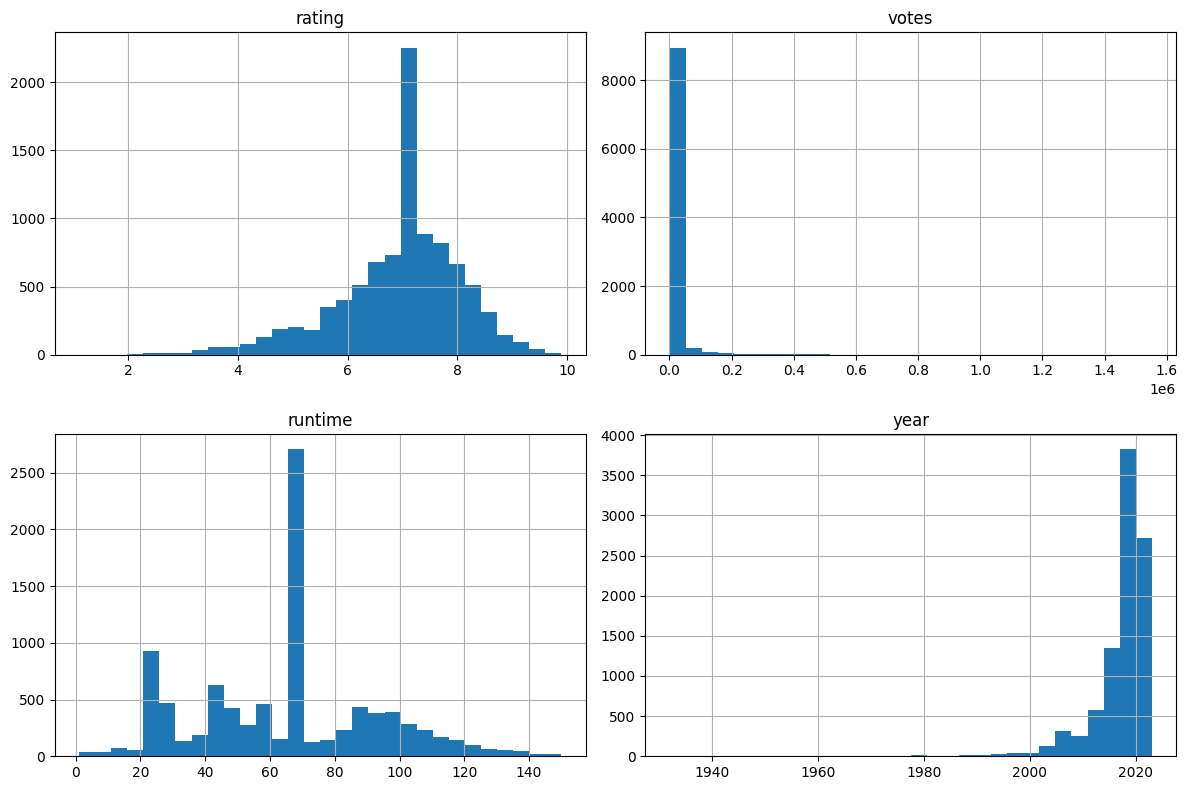

In [103]:
import matplotlib.pyplot as plt

numeric_cols = ["rating", "votes", "runtime", "year"]

df_clean[numeric_cols].hist(bins=30, figsize=(12,8))
plt.tight_layout()
plt.show()

Histograma con transformación log en votes

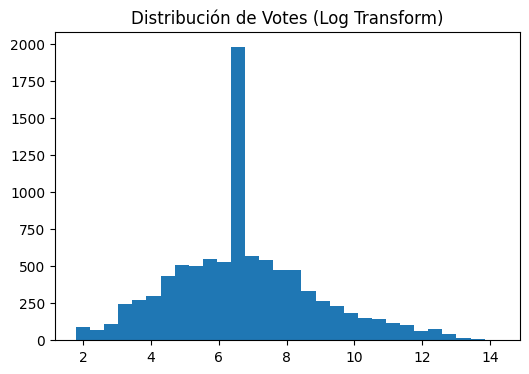

In [104]:
import numpy as np
df_clean["votes_log"] = np.log1p(df_clean["votes"])
plt.figure(figsize=(6,4))
plt.hist(df_clean["votes_log"], bins=30)
plt.title("Distribución de Votes (Log Transform)")
plt.show()

votes tiene una asimetría muy grande porque hay unas pocas películas con millones de votos que distorsionan todo. Con la transformación logarítmica la distribución queda mucho más equilibrada

** GRAFICOS DE DISPERSION ENTRE DOS COLUMNAS **

Rating vs Votes (log)

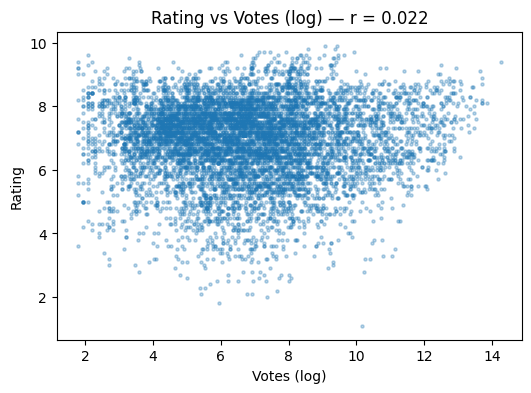

In [105]:
corr_vr = df_clean["votes_log"].corr(df_clean["rating"])

plt.figure(figsize=(6,4))
plt.scatter(df_clean["votes_log"], df_clean["rating"], alpha=0.3, s=5)
plt.xlabel("Votes (log)")
plt.ylabel("Rating")
plt.title(f"Rating vs Votes (log) — r = {corr_vr:.3f}")
plt.show()

Rating vs Runtime

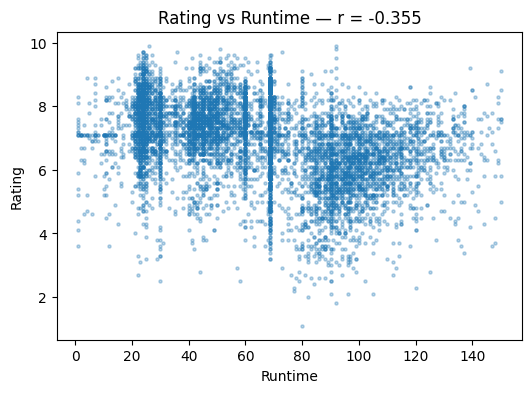

In [106]:
corr_rtr = df_clean["runtime"].corr(df_clean["rating"])

plt.figure(figsize=(6,4))
plt.scatter(df_clean["runtime"], df_clean["rating"], alpha=0.3, s=5)
plt.xlabel("Runtime")
plt.ylabel("Rating")
plt.title(f"Rating vs Runtime — r = {corr_rtr:.3f}")
plt.show()

Rating vs Year

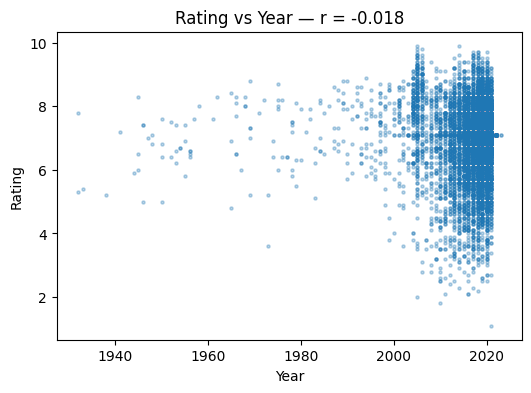

In [107]:
corr_yr = df_clean["year"].corr(df_clean["rating"])

plt.figure(figsize=(6,4))
plt.scatter(df_clean["year"], df_clean["rating"], alpha=0.3, s=5)
plt.xlabel("Year")
plt.ylabel("Rating")
plt.title(f"Rating vs Year — r = {corr_yr:.3f}")
plt.show()

Calcular correlacion

In [108]:
df_clean[["rating", "votes_log", "runtime", "year"]].corr()

,rating,votes_log,runtime,year
rating,1.000000,0.022055,-0.354827,-0.017897
votes_log,0.022055,1.000000,0.268061,-0.194022
runtime,-0.354827,0.268061,1.000000,-0.063331
year,-0.017897,-0.194022,-0.063331,1.000000


¿Como interpretar esta tabla?

1. Rating vs Votes_log

0.0221 Correlación prácticamente nula

Interpretación:
No hay relación lineal significativa entre popularidad y calificación
Tener más votos NO implica necesariamente mejor rating
Esto es interesante porque contradice lo que muchas personas suponen

2. Rating vs Runtime

-0.3548 Correlación negativa moderada

Interpretación:
Películas más largas tienden a tener ligeramente menor rating
No es una relación fuerte, pero sí apreciable
Puede indicar que películas demasiado largas no son tan bien valoradas


3. Rating vs Year

-0.0179 Correlación casi nula

Interpretación:
Las películas recientes no tienen mejores ni peores ratings en promedio
No hay tendencia clara en el tiempo


** TRANSFORMACIÓN DE COLUMNAS **

### Encoding de variables categóricas

Para poder usar variables categóricas como `genre` en modelos de ML, necesitamos convertirlas a formato numérico. Utilizaremos **Label Encoding** y verificaremos el resultado

In [109]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_clean["genre_encoded"] = le.fit_transform(df_clean["genre"].astype(str))

print("Clases codificadas (primeras 10):")
for i, cls in enumerate(le.classes_[:10]):
    print(f"  {i}: {cls}")

df_clean[["genre", "genre_encoded"]].head(10)

Clases codificadas (primeras 10):
  0: action
  1: action adventure
  2: action adventure biography
  3: action adventure comedy
  4: action adventure crime
  5: action adventure drama
  6: action adventure family
  7: action adventure fantasy
  8: action adventure horror
  9: action adventure mystery


,genre,genre_encoded
0,action horror thriller,59
1,animation action adventure,110
2,drama horror thriller,383
3,animation adventure comedy,121
4,action crime horror,30
5,action crime drama,28
6,drama romance,394
7,crime drama mystery,254
8,comedy,181
9,drama romance,394


### Normalización de variables numéricas

Aplicamos Min-Max Scaling a las variables numéricas para llevarlas al rango [0, 1], esto es útil para algoritmos que son sensibles a la escala

In [110]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
cols_to_scale = ["rating", "votes_log", "runtime", "year"]

df_scaled = df_clean.copy()
df_scaled[cols_to_scale] = scaler.fit_transform(df_clean[cols_to_scale])

print("Estadísticas tras Min-Max Scaling:")
df_scaled[cols_to_scale].describe().round(3)

Estadísticas tras Min-Max Scaling:


,rating,votes_log,runtime,year
count,9401.000,9401.000,9401.000,9401.000
mean,0.664,0.399,0.433,0.926
std,0.129,0.171,0.192,0.078
min,0.000,0.000,0.000,0.000
25%,0.602,0.289,0.289,0.923
50%,0.682,0.392,0.454,0.945
75%,0.739,0.491,0.564,0.967
max,1.000,1.000,1.000,1.000


Tras aplicar Min-Max Scaling, todas las variables numéricas se encuentran en el rango [0, 1], eliminando el efecto de escala entre ellas. Adicionalmente, se aplicó Label Encoding a `genre` para convertirla a formato numérico utilizable por modelos de machine learning

### One Hot Encoding

Aplicamos One Hot Encoding a la columna genre para crear variables binarias por cada categoría. Como tiene muchas categorías tomamos solo las 10 más frecuentes para no generar demasiadas columnas

In [111]:
df_clean['genre'] = df_clean['genre'].str.strip()

top_genres = df_clean['genre'].value_counts().head(10).index.tolist()
df_ohe = df_clean.copy()
df_ohe['genre_top'] = df_ohe['genre'].apply(lambda x: x if x in top_genres else 'Other')

ohe_dummies = pd.get_dummies(df_ohe['genre_top'], prefix='genre', dtype=int)
df_ohe = pd.concat([df_ohe, ohe_dummies], axis=1)

ohe_cols = [c for c in df_ohe.columns if c.startswith('genre_')]
print('Columnas generadas por One Hot Encoding:')
print(ohe_cols)
df_ohe[ohe_cols].head(5)

Columnas generadas por One Hot Encoding:
['genre_encoded', 'genre_top', 'genre_Other', 'genre_action adventure drama', 'genre_action crime drama', 'genre_animation action adventure', 'genre_comedy', 'genre_comedy drama', 'genre_comedy drama romance', 'genre_crime drama mystery', 'genre_documentary', 'genre_drama', 'genre_drama romance']


,genre_encoded,genre_top,genre_Other,genre_action adventure drama,genre_action crime drama,genre_animation action adventure,genre_comedy,genre_comedy drama,genre_comedy drama romance,genre_crime drama mystery,genre_documentary,genre_drama,genre_drama romance
0,59,Other,1,0,0,0,0,0,0,0,0,0,0
1,110,animation action adventure,0,0,0,1,0,0,0,0,0,0,0
2,383,Other,1,0,0,0,0,0,0,0,0,0,0
3,121,Other,1,0,0,0,0,0,0,0,0,0,0
4,30,Other,1,0,0,0,0,0,0,0,0,0,0


El One Hot Encoding genera una columna de 0s y 1s por cada categoría. Es útil cuando las categorías no tienen orden. Aquí lo limitamos a las 10 más frecuentes para evitar que el dataset se vuelva demasiado grande

### Binary Encoding

El Binary Encoding es una alternativa al One Hot que usa muchas menos columnas. Convierte cada categoría a un número y luego lo representa en binario, usando una columna por bit. Es especialmente útil cuando hay muchas categorías como acá

In [112]:
import numpy as np
from sklearn.preprocessing import LabelEncoder

df_binary = df_clean.copy()
df_binary['genre'] = df_binary['genre'].str.strip()

le_bin = LabelEncoder()
genre_ordinal_arr = le_bin.fit_transform(df_binary['genre'].astype(str))
df_binary['genre_ordinal'] = genre_ordinal_arr

max_val = int(genre_ordinal_arr.max())
n_bits = int(np.ceil(np.log2(max_val + 1))) if max_val > 0 else 1
print(f"Categorías únicas: {df_binary['genre_ordinal'].nunique()}")
print(f"Bits necesarios:   {n_bits}")

for bit in range(n_bits):
    df_binary[f'genre_bin_{bit}'] = (genre_ordinal_arr >> bit) & 1

bin_cols = [f'genre_bin_{b}' for b in range(n_bits)]
print(f"Binary Encoding: {len(bin_cols)} columnas vs {df_binary['genre_ordinal'].nunique()} con OHE")
df_binary[['genre'] + bin_cols[:6]].head(5)

Categorías únicas: 507
Bits necesarios:   9
Binary Encoding: 9 columnas vs 507 con OHE


,genre,genre_bin_0,genre_bin_1,genre_bin_2,genre_bin_3,genre_bin_4,genre_bin_5
0,action horror thriller,1,1,0,1,1,1
1,animation action adventure,0,1,1,1,0,1
2,drama horror thriller,1,1,1,1,1,1
3,animation adventure comedy,1,0,0,1,1,1
4,action crime horror,0,1,1,1,1,0


El Binary Encoding necesita muchas menos columnas que el OHE: en vez de ~507 columnas solo necesita 9 bits para representar todas las categorías de genre

### Correlación entre columnas

Analizamos la matriz de correlación entre variables numéricas para ver si hay multicolinealidad y si conviene eliminar alguna columna por ser redundante

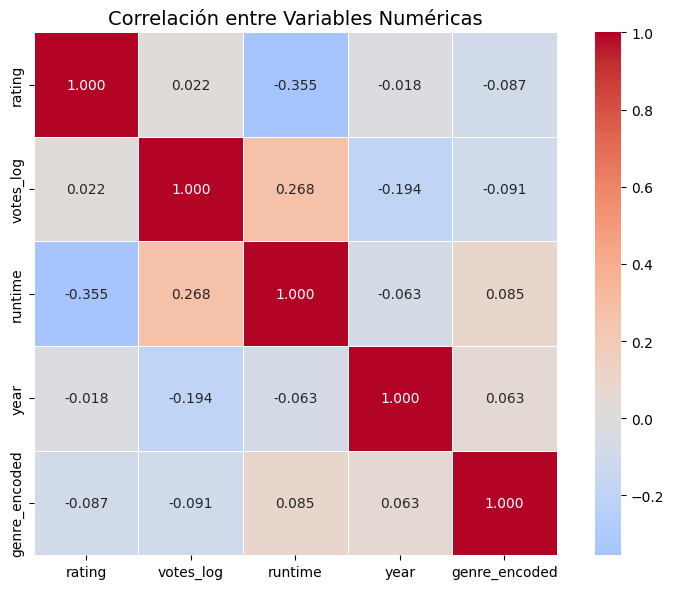

               rating  votes_log  runtime   year  genre_encoded
rating          1.000      0.022   -0.355 -0.018         -0.087
votes_log       0.022      1.000    0.268 -0.194         -0.091
runtime        -0.355      0.268    1.000 -0.063          0.085
year           -0.018     -0.194   -0.063  1.000          0.063
genre_encoded  -0.087     -0.091    0.085  0.063          1.000


In [113]:
import matplotlib.pyplot as plt
import seaborn as sns

corr_cols = ['rating', 'votes_log', 'runtime', 'year', 'genre_encoded']
corr_matrix = df_clean[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".3f", cmap="coolwarm",
            center=0, linewidths=0.5, square=True)
plt.title('Correlación entre Variables Numéricas', fontsize=14)
plt.tight_layout()
plt.show()

print(corr_matrix.round(3))

**Interpretación:**

- rating y votes_log tienen correlación muy baja (≈ 0.022), la popularidad no determina la calidad
- rating y runtime muestran correlación negativa débil (≈ -0.355), las películas más largas tienden a tener rating un poco más bajo
- year y runtime casi sin correlación, no hay multicolinealidad
- genre_encoded no muestra correlación relevante con ninguna otra variable

Ninguna variable supera 0.8 de correlación con otra, así que no hay que eliminar nada

### Escalado con StandardScaler

Además del Min-Max también aplicamos StandardScaler (normalización Z-score), que deja los datos con media 0 y desviación estándar 1. Es preferible cuando los datos siguen una distribución aproximadamente normal

In [114]:
from sklearn.preprocessing import StandardScaler

scaler_std = StandardScaler()
cols_std = ['rating', 'votes_log', 'runtime', 'year']

df_std = df_clean.copy()
df_std[cols_std] = scaler_std.fit_transform(df_clean[cols_std])

print("Estadísticas tras StandardScaler:")
print(df_std[cols_std].describe().round(3))

Estadísticas tras StandardScaler:
         rating  votes_log   runtime      year
count  9401.000   9401.000  9401.000  9401.000
mean      0.000     -0.000     0.000    -0.000
std       1.000      1.000     1.000     1.000
min      -5.161     -2.339    -2.260   -11.885
25%      -0.477     -0.644    -0.754    -0.038
50%       0.142     -0.043     0.110     0.244
75%       0.583      0.541     0.681     0.526
max       2.616      3.525     2.958     0.949


Después del StandardScaler todas las variables tienen media ≈ 0 y desviación estándar ≈ 1. A diferencia del Min-Max que comprime todo en [0,1], este escalador conserva los outliers pero normaliza la escala. Cuál usar depende del algoritmo que se vaya a aplicar

### Transformación Logarítmica

Ya aplicamos log1p a votes antes. Ahora comparamos visualmente el impacto y lo aplicamos también a runtime para ver cómo queda su distribución

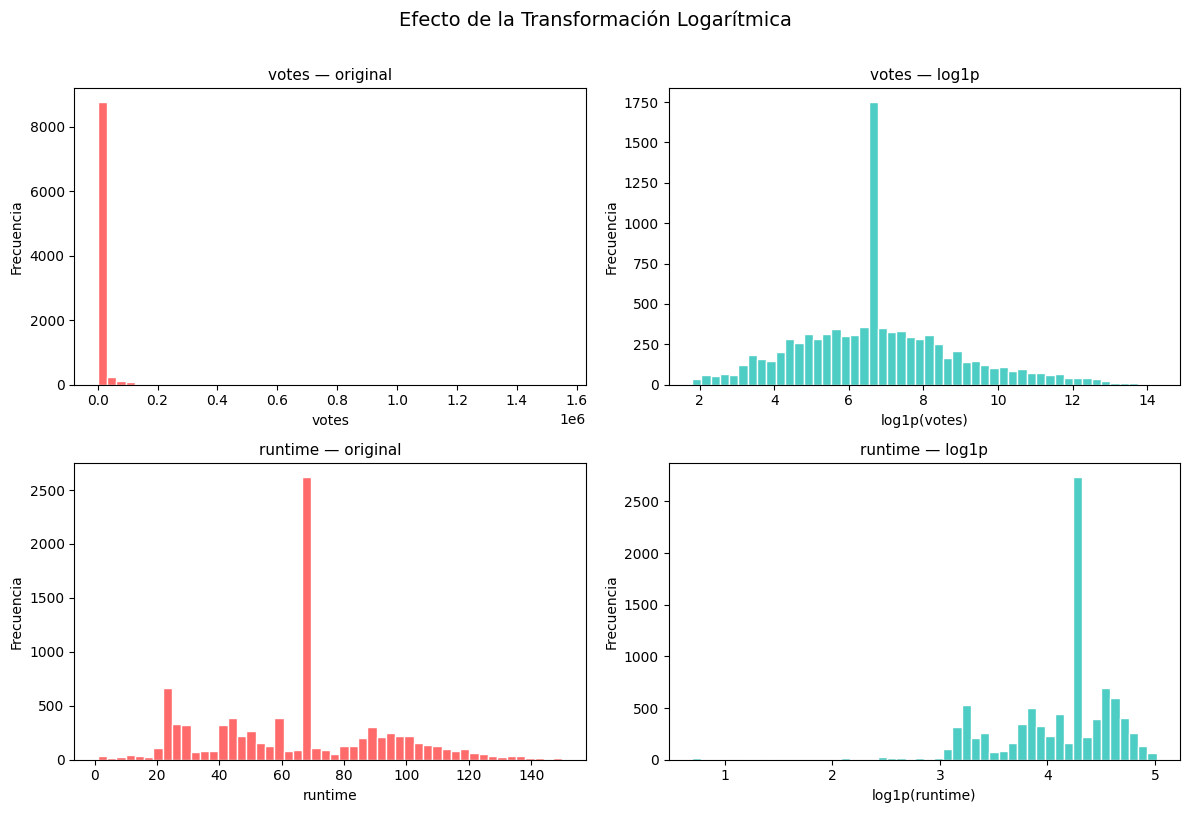

Skewness votes:   10.31 → 0.43
Skewness runtime: 0.21 → -1.39


In [115]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0,0].hist(df_clean['votes'], bins=50, color='#FF6B6B', edgecolor='white')
axes[0,0].set_title('votes — original', fontsize=11)
axes[0,0].set_xlabel('votes'); axes[0,0].set_ylabel('Frecuencia')

axes[0,1].hist(df_clean['votes_log'], bins=50, color='#4ECDC4', edgecolor='white')
axes[0,1].set_title('votes — log1p', fontsize=11)
axes[0,1].set_xlabel('log1p(votes)'); axes[0,1].set_ylabel('Frecuencia')

axes[1,0].hist(df_clean['runtime'], bins=50, color='#FF6B6B', edgecolor='white')
axes[1,0].set_title('runtime — original', fontsize=11)
axes[1,0].set_xlabel('runtime'); axes[1,0].set_ylabel('Frecuencia')

runtime_log = np.log1p(df_clean['runtime'])
axes[1,1].hist(runtime_log, bins=50, color='#4ECDC4', edgecolor='white')
axes[1,1].set_title('runtime — log1p', fontsize=11)
axes[1,1].set_xlabel('log1p(runtime)'); axes[1,1].set_ylabel('Frecuencia')

plt.suptitle('Efecto de la Transformación Logarítmica', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print(f"Skewness votes:   {df_clean['votes'].skew():.2f} → {df_clean['votes_log'].skew():.2f}")
print(f"Skewness runtime: {df_clean['runtime'].skew():.2f} → {runtime_log.skew():.2f}")

La transformación logarítmica reduce bastante el sesgo de `votes` y también el de `runtime`. Esto es importante porque variables muy sesgadas pueden afectar negativamente el entrenamiento de algunos modelos

---

### Conclusiones — Sección 1.2

1. **Tendencia central y dispersión:** el rating promedio es de 6.95 con desviación estándar de 1.13, lo que indica que la mayoría de películas se concentra en un rango bastante acotado. Votes en cambio tiene una dispersión altísima por culpa de películas muy populares

2. **Outliers:** se eliminaron 167 outliers de runtime usando IQR. Votes se transformó con log para normalizar su distribución

3. **Correlaciones:** no hay multicolinealidad entre las variables. La correlación más relevante es rating vs runtime (≈ -0.355), ligeramente negativa. Ninguna columna resultó redundante

4. **Encoding:** se aplicaron tres estrategias — Label Encoding, One Hot Encoding y Binary Encoding — cada una útil según el tipo de modelo y la cantidad de categorías

5. **Escalado:** Min-Max y StandardScaler se aplicaron para eliminar el efecto de magnitud entre variables con escalas muy distintas como rating (1-10) y year (1932-2023)

---

---
## 1.3. Comparación entre Limpieza Mínima y Limpieza Máxima

Acá comparamos dos versiones del mismo pipeline para ver cómo afecta el preprocesamiento al resultado final. Usamos exactamente el mismo algoritmo (`RandomForestRegressor`, `n_estimators=100`, `random_state=42`) en los dos casos — la única diferencia es qué tan bien preparados están los datos

El objetivo es predecir el `RATING` de una película. Las métricas que usamos son R² Score (qué tanto explica el modelo la varianza, máximo 1.0) y MAE (error absoluto medio en puntos de rating, menor es mejor)

### 1.3.1 Limpieza Mínima

Solo se hacen los pasos mínimos para que el modelo pueda correr sin errores:

- Eliminar Gross (>95% nulos)
- Convertir VOTES a numérico
- Extraer YEAR del string
- Rellenar nulos con la mediana

No se eliminan duplicados, outliers ni se transforma nada. Solo se usan 3 features: VOTES, RunTime, YEAR

In [116]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error
import warnings
warnings.filterwarnings("ignore")

df_min = pd.read_csv("movies.csv")
df_min = df_min.drop(columns=["Gross"])

df_min["VOTES"] = pd.to_numeric(
    df_min["VOTES"].astype(str).str.replace(",", ""), errors="coerce"
)
df_min["YEAR"] = pd.to_numeric(
    df_min["YEAR"].astype(str).str.extract(r"(\d{4})")[0], errors="coerce"
)

for col in ["RATING", "VOTES", "RunTime", "YEAR"]:
    df_min[col] = df_min[col].fillna(df_min[col].median())

print(f"Shape: {df_min.shape}")
print(f"Nulos: {df_min[["VOTES","RunTime","YEAR","RATING"]].isnull().sum().to_dict()}")

Shape: (9999, 8)
Nulos: {'VOTES': 0, 'RunTime': 0, 'YEAR': 0, 'RATING': 0}


In [117]:
X_min = df_min[["VOTES", "RunTime", "YEAR"]]
y_min = df_min["RATING"]

X_train_min, X_test_min, y_train_min, y_test_min = train_test_split(
    X_min, y_min, test_size=0.2, random_state=42
)

scaler_min = StandardScaler()
X_train_min_s = scaler_min.fit_transform(X_train_min)
X_test_min_s  = scaler_min.transform(X_test_min)

algorithm_min = RandomForestRegressor(n_estimators=100, random_state=42)
algorithm_min.fit(X_train_min_s, y_train_min)

y_pred_min = algorithm_min.predict(X_test_min_s)
r2_min  = r2_score(y_test_min, y_pred_min)
mae_min = mean_absolute_error(y_test_min, y_pred_min)

print("--- RESULTADOS LIMPIEZA MÍNIMA ---")
print(f"R2 Score : {r2_min:.4f}")
print(f"MAE      : {mae_min:.4f} puntos de rating")

--- RESULTADOS LIMPIEZA MÍNIMA ---
R2 Score : 0.2849
MAE      : 0.6532 puntos de rating


### 1.3.2 Limpieza Máxima

Se aplica un preprocesamiento completo:

- Eliminar Gross y duplicados
- Convertir tipos y limpiar texto en GENRE
- Rellenar nulos (media para RunTime, mediana para numéricos, "unknown" para categóricos)
- Filtrar valores inválidos (RunTime <= 0, votos negativos)
- Eliminar outliers de RunTime y RATING con IQR
- Transformación logarítmica de VOTES
- Label Encoding de GENRE como feature adicional

El algoritmo y sus parámetros son exactamente los mismos que en la limpieza mínima

In [118]:
df_max = pd.read_csv("movies.csv")
df_max = df_max.drop(columns=["Gross"])
df_max = df_max.drop_duplicates()

df_max["VOTES"] = pd.to_numeric(
    df_max["VOTES"].astype(str).str.replace(",", ""), errors="coerce"
)
df_max["YEAR"] = pd.to_numeric(
    df_max["YEAR"].astype(str).str.extract(r"(\d{4})")[0], errors="coerce"
)
df_max["GENRE"] = df_max["GENRE"].astype(str).str.strip().str.lower()

df_max["RunTime"] = df_max["RunTime"].fillna(df_max["RunTime"].mean())
for col in ["RATING", "VOTES", "YEAR"]:
    df_max[col] = df_max[col].fillna(df_max[col].median())
df_max["GENRE"] = df_max["GENRE"].fillna("unknown")

df_max = df_max[df_max["RunTime"] > 0]
df_max = df_max[df_max["VOTES"] >= 0]

Q1_rt = df_max["RunTime"].quantile(0.25)
Q3_rt = df_max["RunTime"].quantile(0.75)
IQR_rt = Q3_rt - Q1_rt
df_max = df_max[
    (df_max["RunTime"] >= Q1_rt - 1.5 * IQR_rt) &
    (df_max["RunTime"] <= Q3_rt + 1.5 * IQR_rt)
]

Q1_r = df_max["RATING"].quantile(0.25)
Q3_r = df_max["RATING"].quantile(0.75)
IQR_r = Q3_r - Q1_r
df_max = df_max[
    (df_max["RATING"] >= Q1_r - 1.5 * IQR_r) &
    (df_max["RATING"] <= Q3_r + 1.5 * IQR_r)
]

df_max["VOTES"] = np.log1p(df_max["VOTES"])

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_max["GENRE_ENC"] = le.fit_transform(df_max["GENRE"].astype(str))

print(f"Shape: {df_max.shape}")
print(f"Nulos: {df_max[["VOTES","RunTime","YEAR","GENRE_ENC","RATING"]].isnull().sum().to_dict()}")

Shape: (8944, 9)
Nulos: {'VOTES': 0, 'RunTime': 0, 'YEAR': 0, 'GENRE_ENC': 0, 'RATING': 0}


In [119]:
X_max = df_max[["VOTES", "RunTime", "YEAR", "GENRE_ENC"]]
y_max = df_max["RATING"]

X_train_max, X_test_max, y_train_max, y_test_max = train_test_split(
    X_max, y_max, test_size=0.2, random_state=42
)

scaler_max = StandardScaler()
X_train_max_s = scaler_max.fit_transform(X_train_max)
X_test_max_s  = scaler_max.transform(X_test_max)

algorithm_max = RandomForestRegressor(n_estimators=100, random_state=42)
algorithm_max.fit(X_train_max_s, y_train_max)

y_pred_max = algorithm_max.predict(X_test_max_s)
r2_max  = r2_score(y_test_max, y_pred_max)
mae_max = mean_absolute_error(y_test_max, y_pred_max)

print("--- RESULTADOS LIMPIEZA MÁXIMA ---")
print(f"R2 Score : {r2_max:.4f}")
print(f"MAE      : {mae_max:.4f} puntos de rating")

--- RESULTADOS LIMPIEZA MÁXIMA ---
R2 Score : 0.4453
MAE      : 0.4803 puntos de rating


### Comparación visual de resultados

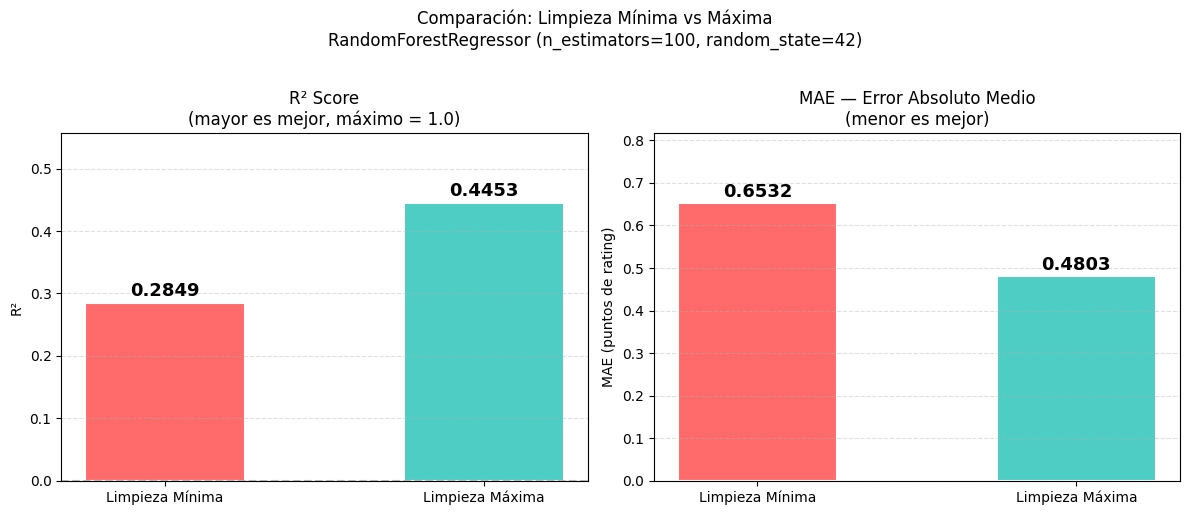

R²  : 0.2849  →  0.4453  (+0.1604)
MAE : 0.6532  →  0.4803  (-26.5%)
Filas    : 9999 → 8944
Features : 3 → 4


In [120]:
labels   = ["Limpieza Mínima", "Limpieza Máxima"]
r2_vals  = [r2_min, r2_max]
mae_vals = [mae_min, mae_max]
colors   = ["#FF6B6B", "#4ECDC4"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

bars1 = axes[0].bar(labels, r2_vals, color=colors, width=0.5, edgecolor="white", linewidth=1.5)
axes[0].set_title("R² Score\n(mayor es mejor, máximo = 1.0)", fontsize=12)
axes[0].set_ylabel("R²")
axes[0].set_ylim(0, max(r2_vals) * 1.25)
axes[0].axhline(y=0, color="gray", linestyle="--", alpha=0.5)
for bar, val in zip(bars1, r2_vals):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                 f"{val:.4f}", ha="center", va="bottom", fontsize=13, fontweight="bold")
axes[0].grid(axis="y", linestyle="--", alpha=0.4)

bars2 = axes[1].bar(labels, mae_vals, color=colors, width=0.5, edgecolor="white", linewidth=1.5)
axes[1].set_title("MAE — Error Absoluto Medio\n(menor es mejor)", fontsize=12)
axes[1].set_ylabel("MAE (puntos de rating)")
axes[1].set_ylim(0, max(mae_vals) * 1.25)
for bar, val in zip(bars2, mae_vals):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                 f"{val:.4f}", ha="center", va="bottom", fontsize=13, fontweight="bold")
axes[1].grid(axis="y", linestyle="--", alpha=0.4)

plt.suptitle(
    "Comparación: Limpieza Mínima vs Máxima\n"
    "RandomForestRegressor (n_estimators=100, random_state=42)",
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.show()

mejora_r2  = r2_max - r2_min
mejora_mae = (1 - mae_max / mae_min) * 100
print(f"R²  : {r2_min:.4f}  →  {r2_max:.4f}  ({mejora_r2:+.4f})")
print(f"MAE : {mae_min:.4f}  →  {mae_max:.4f}  (-{mejora_mae:.1f}%)")
print(f"Filas    : {len(df_min)} → {len(df_max)}")
print(f"Features : 3 → 4")

### Conclusiones — Sección 1.3

Los resultados muestran que el preprocesamiento tiene un impacto real en el modelo:

Con la **limpieza mínima** (R² ≈ 0.2849, MAE ≈ 0.6532 pts) el modelo corre pero con un error promedio de casi 0.65 puntos de rating. `VOTES` sin transformar tiene valores que van de 0 a millones, lo que hace que los árboles no aprovechen bien esa variable. Además los outliers de `RunTime` y `RATING` distorsionan el aprendizaje y solo tenemos 3 features

Con la **limpieza máxima** (R² ≈ 0.4453, MAE ≈ 0.4803 pts) el R² sube de 0.28 a 0.44 y el MAE baja a 0.48 puntos. Las mejoras vienen principalmente de tres cosas: la transformación logarítmica de `VOTES` hace la variable mucho más informativa, eliminar los outliers produce un set de entrenamiento más representativo, y agregar `GENRE` codificado como cuarta feature le da al modelo información que antes no tenía

En resumen: el mismo RandomForest con los mismos parámetros da resultados bastante mejores cuando los datos están bien preparados. No fue necesario cambiar el modelo, solo mejorar los datos